# Adaptive Learning Neural Operator for the Heat Equation

Predicts how heat spreads along a rod for any starting temperature pattern and any material instead of just one fixed situation. To fine tune, the model takes a catalog of untried scenarios, decides which ones it's most unsure about, and uses an FEM only to simulate those. Then it retrains itself and repeats.

A finite-element (FEM) solver is used as ground truth. It's accurate but slow and expensive to run, so the active learning loop calls it only when really needed.

In [21]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve

torch.manual_seed(0)
np.random.seed(0)

In [22]:
L = 1.0 # length
max_time = 3600.0 # max sim time
heater = 100.0 # heater

alphas = (5e-4, 2.5e-3) # range of materials to learn across
sensors = 21 # fixed number of points for the initial conditions

sensor_x = np.linspace(0, L, sensors)


def rand_ic(rng):
    base = rng.uniform(15.0, 30.0)
    temps = np.full(sensors, base)
    bumps = rng.integers(1, 4)
    for _ in range(bumps):
        center = rng.uniform(0.1, L)
        width = rng.uniform(0.05, 0.3)
        height = rng.uniform(-10, 20)
        temps += height * np.exp(-((sensor_x - center) ** 2) / (2 * width ** 2))
    temps[0] = heater
    return temps


def rand_mat(rng):
    return rng.uniform(*alphas)

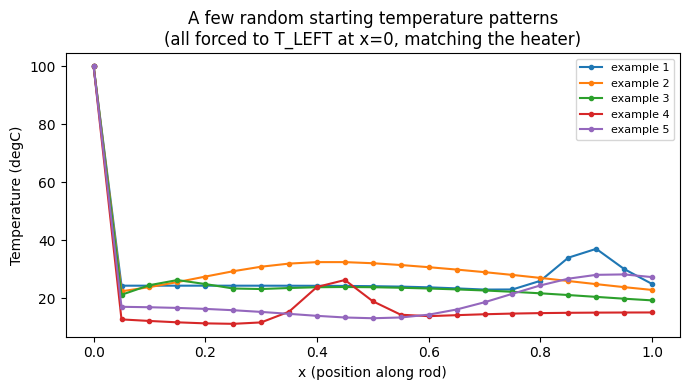

In [23]:
demo_rng = np.random.default_rng(7)

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(5):
    ic = rand_ic(demo_rng)
    ax.plot(sensor_x, ic, marker='o', markersize=3, label=f'example {i+1}')
ax.set_xlabel('x (position along rod)')
ax.set_ylabel('Temperature (C)')
ax.set_title('A few random starting temperature patterns\n(all forced to heater at x=0, matching the heater)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [24]:
num_nodes = 101
time_step = 0.5
x_nodes = np.linspace(0, L, num_nodes)
h = x_nodes[1] - x_nodes[0]

M = np.zeros((num_nodes, num_nodes))
K = np.zeros((num_nodes, num_nodes))
M_local = (h / 6.0) * np.array([[2, 1], [1, 2]]) # M controls how neighboring points influence each other
K_local = (1.0 / h) * np.array([[1, -1], [-1, 1]]) # K controls how heat flows from high to low
for e in range(num_nodes - 1):
    nodes = [e, e + 1]
    for a in range(2):
        for b in range(2):
            M[nodes[a], nodes[b]] += M_local[a, b]
            K[nodes[a], nodes[b]] += K_local[a, b]


def run_fem(ic_vals, alpha, times):
    n_dt = int(max_time / time_step) # number of times
    dt = max_time / n_dt # new timestep
    A = M + alpha * dt * K
    A[0, :] = 0.0
    A[0, 0] = 1.0
    A_factored = lu_factor(A)

    T = np.interp(x_nodes, sensor_x, ic_vals) # ic
    T[0] = heater

    times = sorted(times)
    results = {}
    t_current = 0.0
    next_idx = 0
    if times and times[0] <= 1e-9:
        results[times[0]] = T.copy()
        next_idx = 1

    for step in range(n_dt):
        rhs = M @ T
        rhs[0] = heater
        T = lu_solve(A_factored, rhs)
        t_current += dt
        while next_idx < len(times) and t_current >= times[next_idx] - 1e-6:
            results[times[next_idx]] = T.copy()
            next_idx += 1

    return results

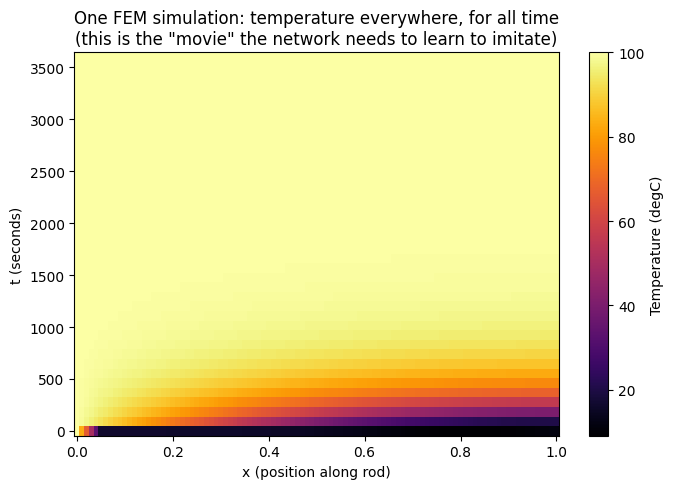

In [25]:
demo_rng2 = np.random.default_rng(3)
ic_demo = rand_ic(demo_rng2)
alpha_demo = rand_mat(demo_rng2)
times_demo = np.linspace(0, max_time, 40)
fem_demo = run_fem(ic_demo, alpha_demo, times_demo)

sorted_times = sorted(fem_demo.keys())
T_grid = np.array([fem_demo[t] for t in sorted_times])  # (n_times, num_nodes)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(x_nodes, sorted_times, T_grid, shading='auto', cmap='inferno')
ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('One FEM simulation')
fig.colorbar(im, ax=ax, label='Temperature (degC)')
plt.tight_layout()
plt.show()

In [26]:
P = 64  # size of branch/trunk space

class DeepONet(nn.Module):
    def __init__(self, sensors=sensors, p=P):
        super().__init__()
        self.branch = nn.Sequential(
            nn.Linear(sensors + 1, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p),
        )
        self.trunk = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, p), nn.Tanh(),
        )
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, ic_batch, alpha_batch, x_batch, t_batch):
        alpha_norm = (alpha_batch - alphas[0]) / (alphas[1] - alphas[0])
        branch_in = torch.cat([ic_batch, alpha_norm.unsqueeze(-1)], dim=-1)
        branch_out = self.branch(branch_in)
        t_norm = t_batch / max_time
        trunk_in = torch.stack([x_batch, t_norm], dim=-1)
        trunk_out = self.trunk(trunk_in)
        return (branch_out * trunk_out).sum(dim=-1) + self.bias

In [28]:
n_samples = 80

def extract(ic_vals, alpha, rng):
    times = sorted(rng.uniform(0, max_time, size=12).tolist() + [0.0])
    fem_result = run_fem(ic_vals, alpha, times)

    egs = []
    for _ in range(n_samples):
        t_val = rng.choice(list(fem_result.keys()))
        x_idx = rng.integers(0, num_nodes)
        x_val = x_nodes[x_idx]
        T_true = fem_result[t_val][x_idx]
        egs.append((ic_vals, alpha, x_val, t_val, T_true))
    return egs


def convert(egs):
    ic = torch.tensor(np.array([e[0] for e in egs]), dtype=torch.float32)
    alpha_t = torch.tensor([e[1] for e in egs], dtype=torch.float32)
    x_t = torch.tensor([e[2] for e in egs], dtype=torch.float32)
    t_t = torch.tensor([e[3] for e in egs], dtype=torch.float32)
    T_t = torch.tensor([e[4] for e in egs], dtype=torch.float32)
    return ic, alpha_t, x_t, t_t, T_t

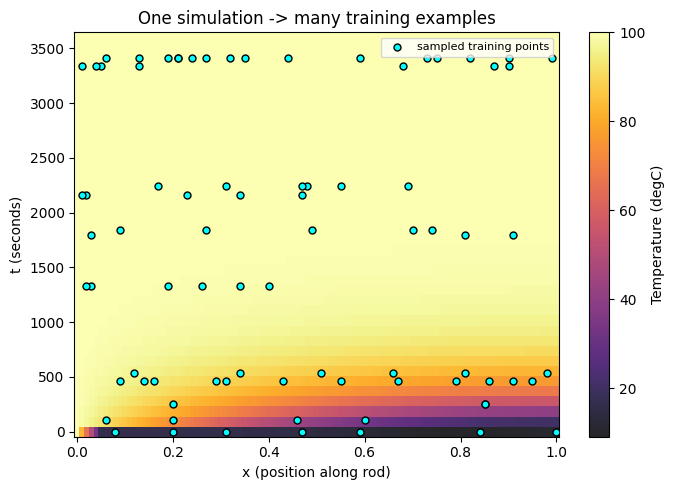

In [29]:
demo_egs = extract(ic_demo, alpha_demo, np.random.default_rng(11))
ex_t = [e[3] for e in demo_egs]
ex_x = [e[2] for e in demo_egs]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(x_nodes, sorted_times, T_grid, shading='auto', cmap='inferno', alpha=0.85)
ax.scatter(ex_x, ex_t, c='cyan', edgecolor='black', s=25, label='sampled training points', zorder=5)
ax.set_xlabel('x (position along rod)')
ax.set_ylabel('t (seconds)')
ax.legend(loc='upper right', fontsize=8)
fig.colorbar(im, ax=ax, label='Temperature (degC)')
plt.tight_layout()
plt.show()

In [30]:
rng = np.random.default_rng(42)

inits = 60
choices = 60
tests = 15

def makelist(n, rng):
    return [(rand_ic(rng), rand_mat(rng)) for _ in range(n)]

init_pool = makelist(inits, rng)
choice_pool = makelist(choices, rng)   # not simulated yet
test_pool = makelist(tests, rng)

print("Simulating inits")
train_egs = []
for ic, alpha in init_pool:
    train_egs.extend(extract(ic, alpha, rng))

print(f"Simulating tests")
femcache = {}
for i, (ic, alpha) in enumerate(test_pool):
    times = list(np.linspace(0, max_time, 8))
    femcache[i] = run_fem(ic, alpha, times)

Simulating 60 initial training scenarios via FEM...
  -> 4800 supervised (ic, alpha, x, t) -> T examples
Simulating 15 held-out test scenarios via FEM...
  done -- this test set is never used for training or for active learning selection


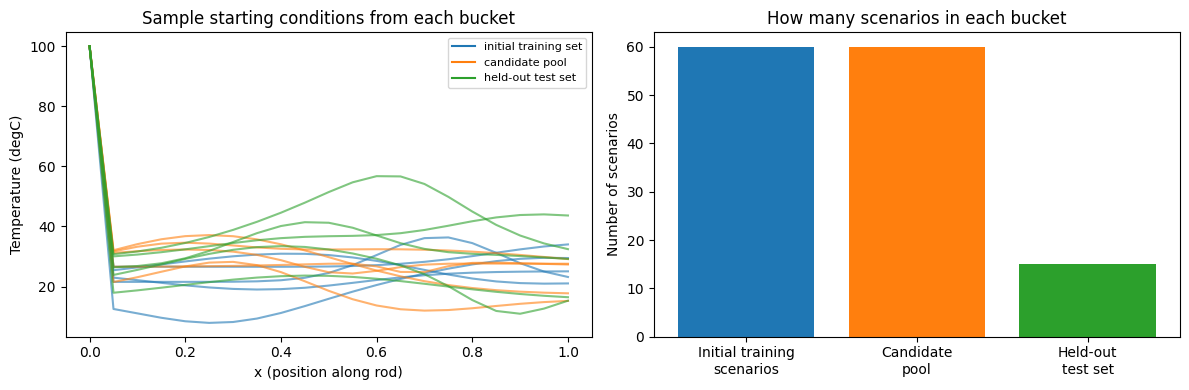

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ic, _ in init_pool[:5]:
    axes[0].plot(sensor_x, ic, color='tab:blue', alpha=0.6)
for ic, _ in choice_pool[:5]:
    axes[0].plot(sensor_x, ic, color='tab:orange', alpha=0.6)
for ic, _ in test_pool[:5]:
    axes[0].plot(sensor_x, ic, color='tab:green', alpha=0.6)
axes[0].plot([], [], color='tab:blue', label='initial training set')
axes[0].plot([], [], color='tab:orange', label='candidate pool')
axes[0].plot([], [], color='tab:green', label='held-out test set')
axes[0].set_xlabel('x (position along rod)')
axes[0].set_ylabel('Temperature (degC)')
axes[0].set_title('Sample starting conditions from each bucket')
axes[0].legend(fontsize=8)

bucket_names = ['Initial training\nscenarios', 'Candidate\npool', 'Held-out\ntest set']
bucket_counts = [len(init_pool), len(choice_pool), len(test_pool)]
axes[1].bar(bucket_names, bucket_counts, color=['tab:blue', 'tab:orange', 'tab:green'])
axes[1].set_ylabel('Number of scenarios')
axes[1].set_title('How many scenarios in each bucket')

plt.tight_layout()
plt.show()

In [32]:
ens_n = 3
w_data = 1.0
w_phy = 0.02

def train1(model, train_egs, pool, epochs, lr=2e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, max_time=epochs, eta_min=1e-5)
    ic_t, alpha_t, x_t, t_t, T_t = convert(train_egs)
    for epoch in range(epochs):
        opt.zero_grad()
        pred = model(ic_t, alpha_t, x_t, t_t)
        data_loss = torch.mean((pred - T_t) ** 2)

        # ---- physics residual on a random scenario from the pool ----
        ic_np, alpha_val = pool[np.random.randint(len(pool))]
        n_phys = 64
        ic_phys = torch.tensor(np.tile(ic_np, (n_phys, 1)), dtype=torch.float32)
        alpha_phys = torch.full((n_phys,), alpha_val, dtype=torch.float32)
        x_phys = (torch.rand(n_phys) * L).requires_grad_(True)
        t_phys = (torch.rand(n_phys) * max_time).requires_grad_(True)

        T_phys = model(ic_phys, alpha_phys, x_phys, t_phys)
        dT_dx = torch.autograd.grad(T_phys, x_phys, torch.ones_like(T_phys), create_graph=True)[0]
        d2T_dx2 = torch.autograd.grad(dT_dx, x_phys, torch.ones_like(dT_dx), create_graph=True)[0]
        dT_dt = torch.autograd.grad(T_phys, t_phys, torch.ones_like(T_phys), create_graph=True)[0]
        residual = dT_dt - alpha_val * d2T_dx2
        physics_loss = torch.mean(residual ** 2)

        loss = w_data * data_loss + w_phy * physics_loss
        loss.backward()
        opt.step()
        sched.step()
        if epoch % 500 == 0:
          print(f"Epoch {epoch}: data loss = {data_loss.item():.4f}, physics loss = {physics_loss.item():.4f}")

    return model


def train2(train_egs, pool, epochs, ens_n=ens_n, existing=None):
    models = []
    for i in range(ens_n):
        if existing is not None:
            model = existing[i]
        else:
            torch.manual_seed(100 + i)
            model = DeepONet()
        model = train1(model, train_egs, pool, epochs)
        models.append(model)
    return models

### 7.1 Initial ensemble training

In [33]:
epoch_n = 1500

ensemble = train2(train_egs, init_pool, epochs=epoch_n)
print(f"Trained {ens_n} models on {len(train_egs)} egs")

Epoch 0: data loss = 8387.6611, physics loss = 0.0000
Epoch 500: data loss = 36.4400, physics loss = 0.0041
Epoch 1000: data loss = 24.8684, physics loss = 0.0155
Epoch 0: data loss = 8347.2432, physics loss = 0.0000
Epoch 500: data loss = 27.2607, physics loss = 0.0022
Epoch 1000: data loss = 15.9569, physics loss = 0.0013
Epoch 0: data loss = 8421.1025, physics loss = 0.0000
Epoch 500: data loss = 31.3539, physics loss = 0.0005
Epoch 1000: data loss = 19.7051, physics loss = 0.2156
Trained initial ensemble of 3 models on 4800 examples


In [34]:
def predict(models, ic_batch, alpha_batch, x_batch, t_batch):
    with torch.no_grad():
        preds = torch.stack([m(ic_batch, alpha_batch, x_batch, t_batch) for m in models])
    return preds.mean(dim=0), preds.std(dim=0)


def uncertain(models, ic, alpha, n_query=30):
    ic_t = torch.tensor(np.tile(ic, (n_query, 1)), dtype=torch.float32)
    alpha_t = torch.full((n_query,), alpha, dtype=torch.float32)
    x_t = torch.rand(n_query) * L
    t_t = torch.rand(n_query) * max_time
    _, std = predict(models, ic_t, alpha_t, x_t, t_t)
    return std.mean().item()


def eval(models):
    errors = []
    for i, (ic, alpha) in enumerate(test_pool):
        fem_result = femcache[i]
        for t_val, T_field in fem_result.items():
            n_sample = 10
            idxs = np.random.choice(num_nodes, n_sample, replace=False)
            ic_t = torch.tensor(np.tile(ic, (n_sample, 1)), dtype=torch.float32)
            alpha_t = torch.full((n_sample,), alpha, dtype=torch.float32)
            x_t = torch.tensor(x_nodes[idxs], dtype=torch.float32)
            t_t = torch.full((n_sample,), float(t_val), dtype=torch.float32)
            pred, _ = predict(models, ic_t, alpha_t, x_t, t_t)
            true_vals = T_field[idxs]
            errors.append(np.abs(pred.numpy() - true_vals))
    errors = np.concatenate(errors)
    return errors.mean(), errors.max()


mean_err, max_err = eval(ensemble)
print(f"mean error = {mean_err:.3f} degC, max error = {max_err:.3f} degC")

Initial ensemble -- held-out test set: mean |error| = 2.314 degC, max |error| = 30.028 degC


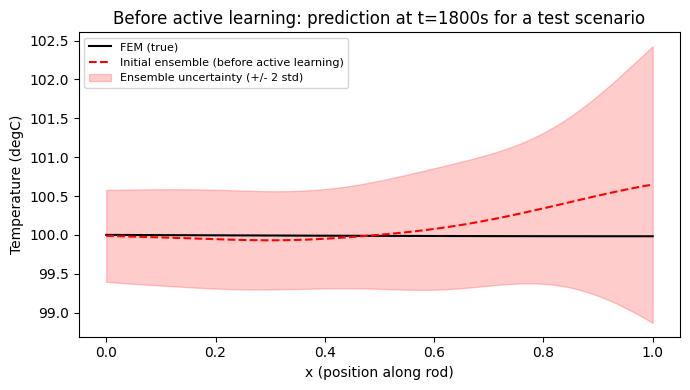

In [35]:
demo_test_idx = 0
demo_ic2, demo_alpha2 = test_pool[demo_test_idx]
demo_t2 = max_time * 0.5

x_query2 = torch.tensor(x_nodes, dtype=torch.float32)
ic_query2 = torch.tensor(np.tile(demo_ic2, (num_nodes, 1)), dtype=torch.float32)
alpha_query2 = torch.full((num_nodes,), demo_alpha2, dtype=torch.float32)
t_query2 = torch.full((num_nodes,), demo_t2, dtype=torch.float32)

mean_pred0, std_pred0 = predict(ensemble, ic_query2, alpha_query2, x_query2, t_query2)
true_field0 = run_fem(demo_ic2, demo_alpha2, [demo_t2])[demo_t2]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_nodes, true_field0, 'k-', label='FEM')
ax.plot(x_nodes, mean_pred0.numpy(), 'r--', label='Initial ensemble')
ax.fill_between(x_nodes, (mean_pred0 - 2*std_pred0).numpy(), (mean_pred0 + 2*std_pred0).numpy(),
                 alpha=0.2, color='red', label='Ensemble uncertainty (+/- 2 std)')
ax.set_xlabel('x')
ax.set_ylabel('Temp')
ax.set_title(f'Before active learning: prediction at t={demo_t2:.0f}s for a test scenario')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [38]:
rounds = 4
k = 6
epoch_n2 = 250

def act_learn(strat, seed_offset):
    torch.manual_seed(200 + seed_offset)
    models = train2(train_egs, init_pool, epochs=epoch_n, ens_n=ens_n)

    current_egs = list(train_egs)
    remains = list(choice_pool)
    hist = []

    mean_err, _ = eval(models)
    hist.append({"round": 0, "size": len(current_egs), "err": mean_err})
    print(f"[{strat}] round 0 test mean error: {mean_err:.3f} degC")

    for round_idx in range(1, rounds + 1):
        if strat == "uncertainty":
            scores = [uncertain(models, ic, alpha) for ic, alpha in remains]
            order = np.argsort(scores)[::-1]
            chosen_idx = order[:k]
        else:
            chosen_idx = np.random.choice(len(remains), size=k, replace=False)

        chosen = [remains[i] for i in chosen_idx]
        remains = [s for j, s in enumerate(remains) if j not in set(chosen_idx)]

        for ic, alpha in chosen:
            current_egs.extend(extract(ic, alpha, rng))

        models = train2(current_egs, init_pool + chosen, epochs=epoch_n2,
                                 ens_n=ens_n, existing=models)

        mean_err, _ = eval(models)
        hist.append({"round": round_idx, "size": len(current_egs), "err": mean_err})
        print(f"[{strat}] round {round_idx} dataset size {len(current_egs)} test mean error: {mean_err:.3f} degC")

    return models, hist


print("Uncertainty-guided active learning")
al_models, al_hist = act_learn("uncertainty", seed_offset=0)

print()
print("Random-selection baseline")
base_models, base_hist = act_learn("random", seed_offset=1)

bl_models, bl_hist = base_models, base_hist
al_errors = [h["err"] for h in al_hist]
bl_errors = [h["err"] for h in bl_hist]

=== Uncertainty-guided active learning ===
Epoch 0: data loss = 8387.6611, physics loss = 0.0000
Epoch 500: data loss = 36.4400, physics loss = 0.0068
Epoch 1000: data loss = 24.8683, physics loss = 0.0092
Epoch 0: data loss = 8347.2432, physics loss = 0.0000
Epoch 500: data loss = 27.2629, physics loss = 0.0017
Epoch 1000: data loss = 15.9569, physics loss = 0.0012
Epoch 0: data loss = 8421.1025, physics loss = 0.0000
Epoch 500: data loss = 31.3539, physics loss = 0.0005
Epoch 1000: data loss = 19.7142, physics loss = 0.0487
[uncertainty] round 0 (initial) -- test mean error: 2.391 degC
Epoch 0: data loss = 23.8172, physics loss = 0.0012
Epoch 0: data loss = 17.4862, physics loss = 0.0363
Epoch 0: data loss = 19.7059, physics loss = 0.0015
[uncertainty] round 1 -- dataset size 5280 -- test mean error: 2.094 degC
Epoch 0: data loss = 20.2807, physics loss = 0.0264
Epoch 0: data loss = 14.3267, physics loss = 0.0979
Epoch 0: data loss = 16.2121, physics loss = 0.0559
[uncertainty] round

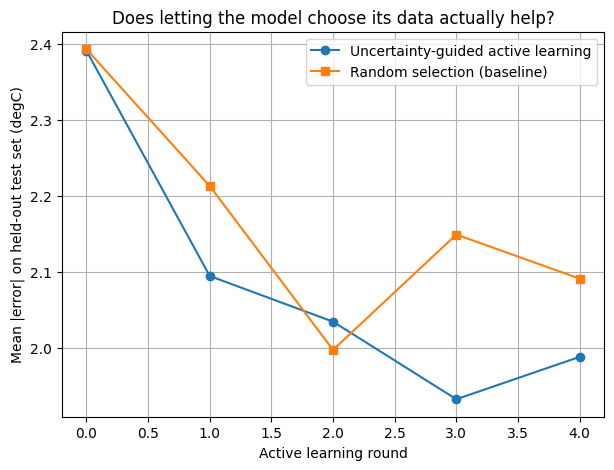

Final uncertainty-guided error: 1.988 degC
Final random-baseline error:    2.091 degC
Active learning outperformed random selection on this run.


In [39]:
al_rounds = [h["round"] for h in al_hist]
al_errors = [h["err"] for h in al_hist]
bl_errors = [h["err"] for h in base_hist]

plt.figure(figsize=(7, 5))
plt.plot(al_rounds, al_errors, marker='o', label='Uncertainty-guided active learning')
plt.plot(al_rounds, bl_errors, marker='s', label='Random selection')
plt.xlabel('Active learning')
plt.ylabel('Mean error on held-out test set (degC)')
plt.title('Does letting the model choose its data help?')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final uncertainty-guided error: {al_errors[-1]:.3f} degC")
print(f"Final random-base error:    {bl_errors[-1]:.3f} degC")

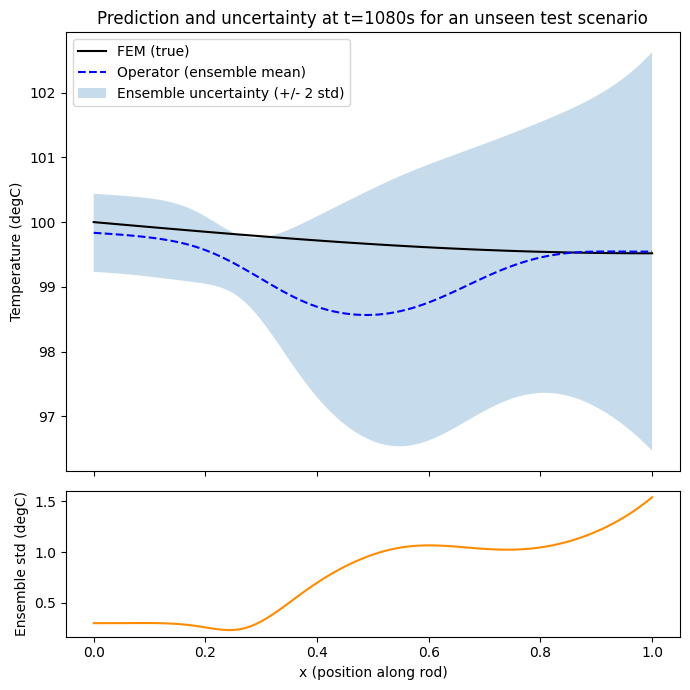

In [41]:
demo_ic, demo_alpha = test_pool[0]
demo_t = max_time * 0.3

x_query = torch.tensor(x_nodes, dtype=torch.float32)
ic_query = torch.tensor(np.tile(demo_ic, (num_nodes, 1)), dtype=torch.float32)
alpha_query = torch.full((num_nodes,), demo_alpha, dtype=torch.float32)
t_query = torch.full((num_nodes,), demo_t, dtype=torch.float32)

mean_pred, std_pred = predict(al_models, ic_query, alpha_query, x_query, t_query)
true_field = run_fem(demo_ic, demo_alpha, [demo_t])[demo_t]

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(x_nodes, true_field, 'k-', label='FEM (true)')
axes[0].plot(x_nodes, mean_pred.numpy(), 'b--', label='Operator (ensemble mean)')
axes[0].fill_between(x_nodes, (mean_pred - 2*std_pred).numpy(), (mean_pred + 2*std_pred).numpy(),
                       alpha=0.25, label='Ensemble uncertainty (+/- 2 std)')
axes[0].set_ylabel('Temperature (degC)')
axes[0].legend()
axes[0].set_title(f'Prediction and uncertainty at t={demo_t:.0f}s for an unseen test scenario')

axes[1].plot(x_nodes, std_pred.numpy(), color='darkorange')
axes[1].set_ylabel('Ensemble std (degC)')
axes[1].set_xlabel('x')

plt.tight_layout()
plt.show()